In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv("/content/cleane_used cars.csv")

In [9]:
df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner,Engine_CC,Mileage_kmpl,Price_INR,City
0,1,2,12,2016,69196,2,1,1,1598.0,23.3,1293716,3
1,4,5,19,2011,29312,1,1,3,1998.0,16.2,704740,3
2,6,4,19,2010,66024,2,0,3,1497.0,21.4,915108,0
3,7,3,21,2014,180682,1,1,2,1498.0,23.1,492679,4
4,8,6,15,2015,184467,1,1,2,1998.0,10.6,811552,4


In [10]:
df.tail()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner,Engine_CC,Mileage_kmpl,Price_INR,City
165,198,6,23,2017,213864,0,1,4,1248.0,27.4,1791868,2
166,199,4,4,2009,157967,1,1,4,1197.0,24.8,657923,3
167,6,4,19,2010,66024,2,0,3,1497.0,21.4,915108,0
168,26,7,18,2023,45579,2,0,2,998.0,20.4,1287065,3
169,51,8,11,2024,151518,0,0,4,1498.0,24.7,1208596,4


In [11]:
# divide Dependent & Independent Variable
X = df.drop('Price_INR', axis=1)
y = df['Price_INR']

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [16]:
#Make Prediction
y_pred=model.predict(X_test)

In [17]:
mae=mean_squared_error(y_test,y_pred)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 211829860979.6151


In [18]:
mae=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("R2 Score:",r2)

Mean Absolute Error: 211829860979.6151
R2 Score: -0.08460264846610066


In [19]:
mae = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("MAE:",mae)
print("r2:",r2)
print("RMSE:",mse)

MAE: 211829860979.6151
r2: -0.08460264846610066
RMSE: 211829860979.6151


In [20]:
results=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
results

,Actual,Predicted
139,1124384,1.193860e+06
30,914729,8.796666e+05
119,1248829,1.038321e+06
29,1599173,1.001321e+06
144,217916,1.065822e+06
163,1108374,9.076858e+05
166,657923,1.013928e+06
51,945085,9.601987e+05
105,1644013,8.832184e+05
60,793035,8.074441e+05


In [21]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.head(10)

,Actual,Predicted
139,1124384,1.193860e+06
30,914729,8.796666e+05
119,1248829,1.038321e+06
29,1599173,1.001321e+06
144,217916,1.065822e+06
163,1108374,9.076858e+05
166,657923,1.013928e+06
51,945085,9.601987e+05
105,1644013,8.832184e+05
60,793035,8.074441e+05


In [22]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(mae)

371299.4849780214


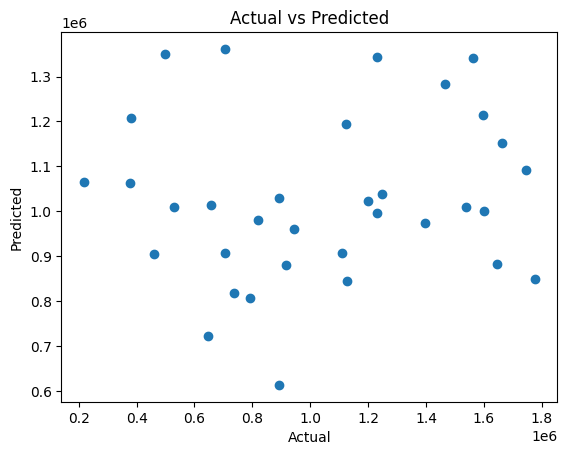

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

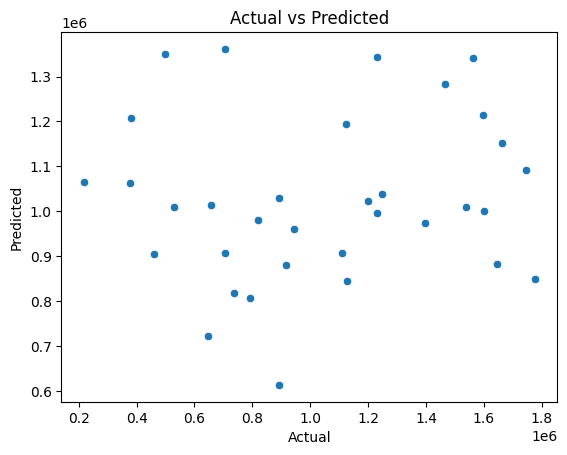

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Re-defining variables needed for plotting, which are typically defined in preceding cells
df = pd.read_csv("/content/cleane_used cars.csv")
X = df.drop('Price_INR', axis=1)
y = df['Price_INR']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

### 1. Distribution of Car Prices (Price_INR)

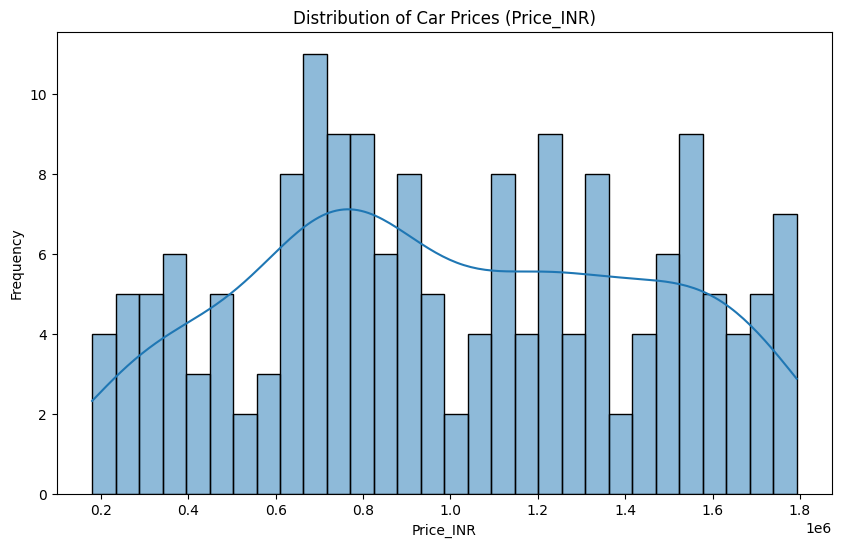

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_INR'], kde=True, bins=30)
plt.title('Distribution of Car Prices (Price_INR)')
plt.xlabel('Price_INR')
plt.ylabel('Frequency')
plt.show()

### 2. Price by Fuel Type

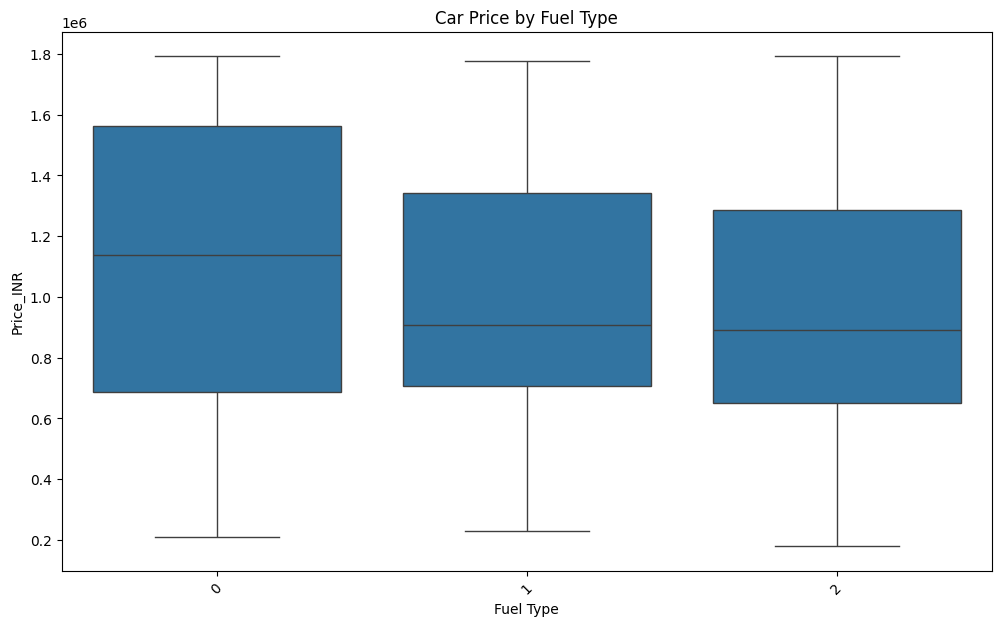

In [26]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Fuel_Type', y='Price_INR', data=df)
plt.title('Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price_INR')
plt.xticks(rotation=45)
plt.show()

### 3. Correlation Heatmap of Numerical Features

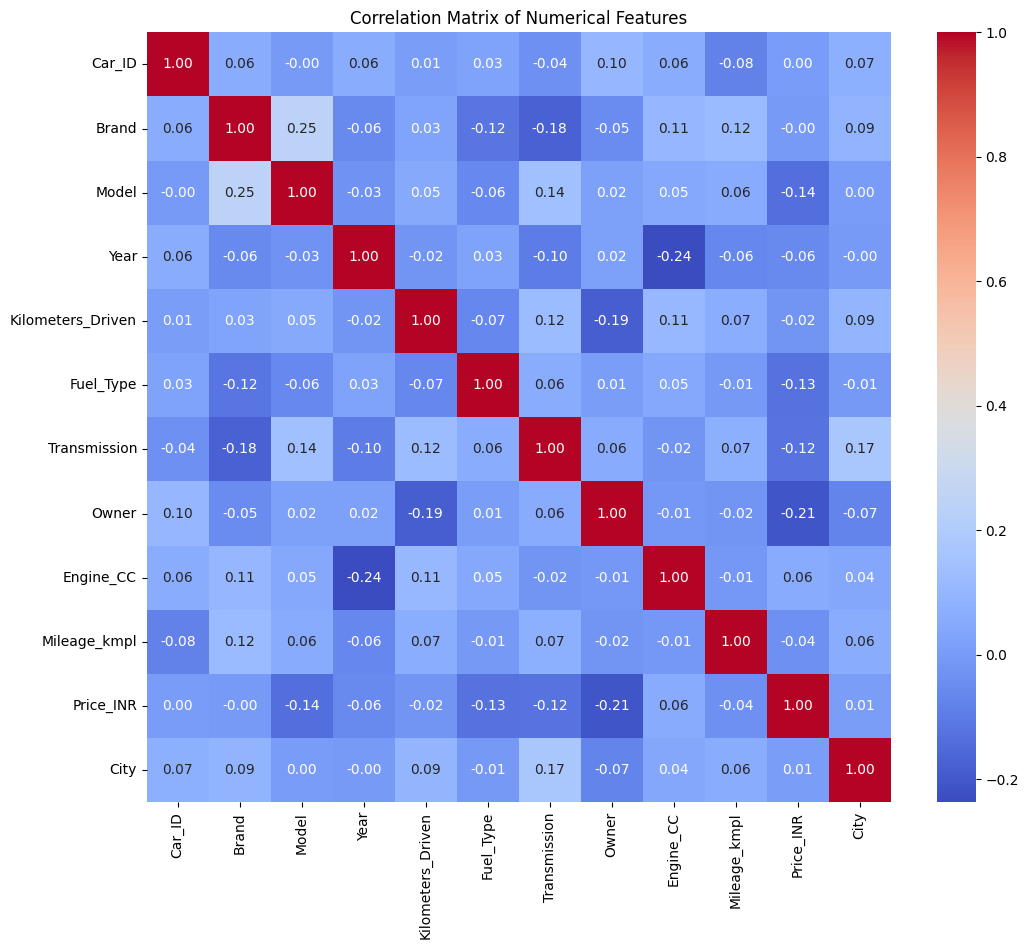

In [28]:
plt.figure(figsize=(12, 10))
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### 4. Residual Plot

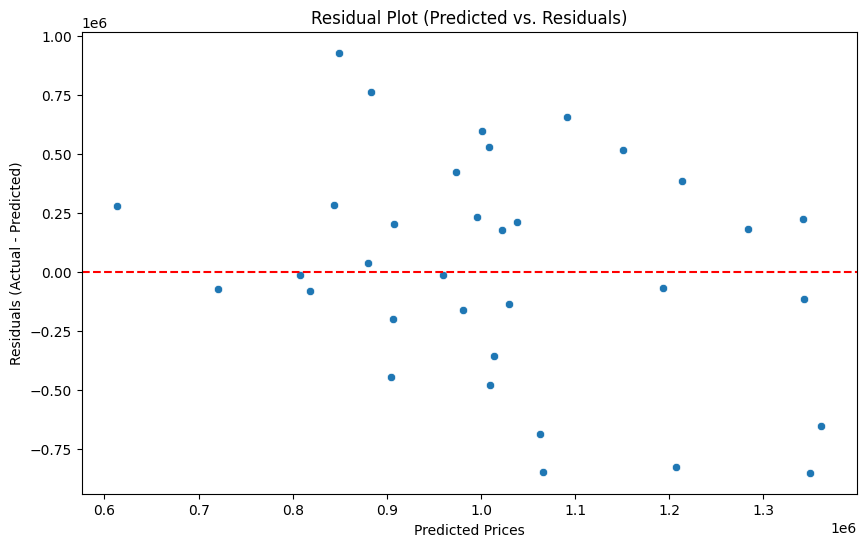

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

### 5. Histogram of Residuals

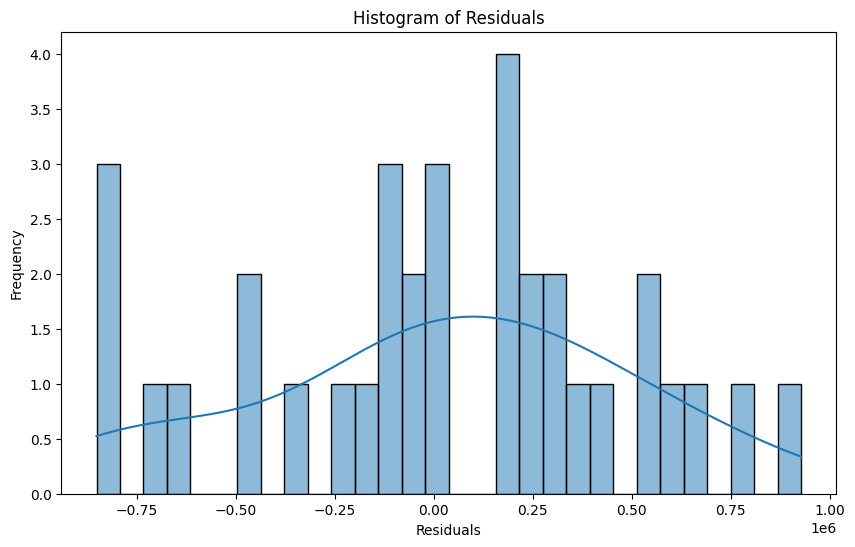

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

### Implementing a Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regressor trained and predictions made.")

Random Forest Regressor trained and predictions made.


### Evaluate Random Forest Regressor Performance

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf}")
print(f"Random Forest R2 Score: {r2_rf}")

Random Forest MAE: 381453.5711764706
Random Forest R2 Score: -0.04707819517233491


### Visualize Random Forest Residuals

Let's plot the residuals for the Random Forest model to see if the heteroscedasticity has been reduced.

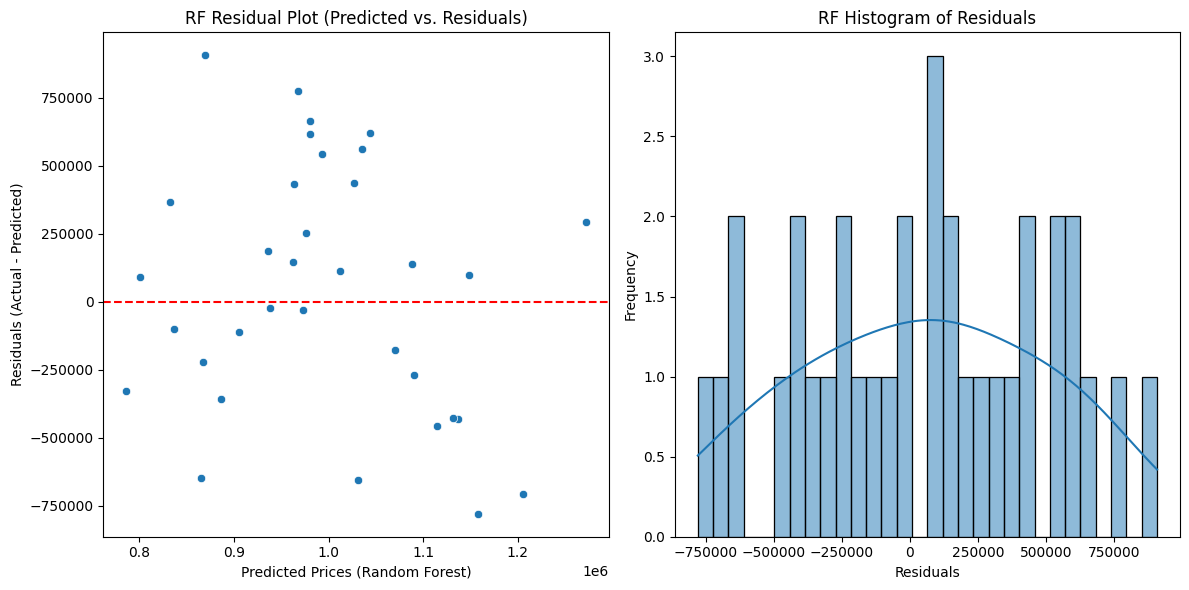

In [36]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Prices (Random Forest)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf, kde=True, bins=30)
plt.title('RF Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Applying Log Transformation to Target Variable

In [46]:
import numpy as np

# Apply log transformation to the target variable
y_log = np.log1p(df['Price_INR'])

# Re-split the data with the log-transformed target
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

print("Log transformation applied to Price_INR and data re-split.")

Log transformation applied to Price_INR and data re-split.


### Re-training and Evaluating Linear Regression with Log-Transformed Target

Linear Regression (Log-Transformed) MAE: 377854.2805477502
Linear Regression (Log-Transformed) R2 Score: -0.15992738281238084


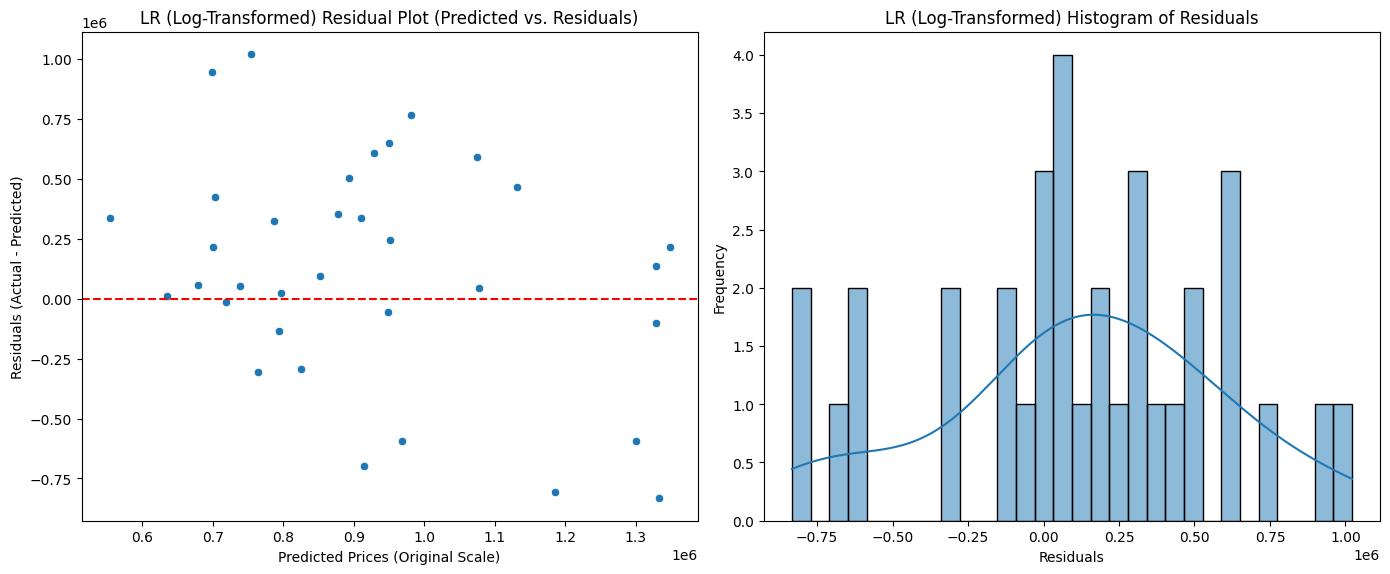

In [47]:
# Train Linear Regression model on log-transformed data
lr_model_log = LinearRegression()
lr_model_log.fit(X_train_log, y_train_log)

# Make predictions and inverse transform them
y_pred_log_lr = lr_model_log.predict(X_test_log)
y_pred_lr_original = np.expm1(y_pred_log_lr) # Inverse log1p

# Evaluate performance on original scale
mae_lr_log = mean_absolute_error(y_test, y_pred_lr_original)
r2_lr_log = r2_score(y_test, y_pred_lr_original)

print(f"Linear Regression (Log-Transformed) MAE: {mae_lr_log}")
print(f"Linear Regression (Log-Transformed) R2 Score: {r2_lr_log}")

# Plot residuals for Linear Regression (log-transformed target)
residuals_lr_log = y_test - y_pred_lr_original

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_lr_original, y=residuals_lr_log)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('LR (Log-Transformed) Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_lr_log, kde=True, bins=30)
plt.title('LR (Log-Transformed) Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Re-training and Evaluating Random Forest with Log-Transformed Target

Random Forest (Log-Transformed) MAE: 395034.5238196462
Random Forest (Log-Transformed) R2 Score: -0.23874187007890058


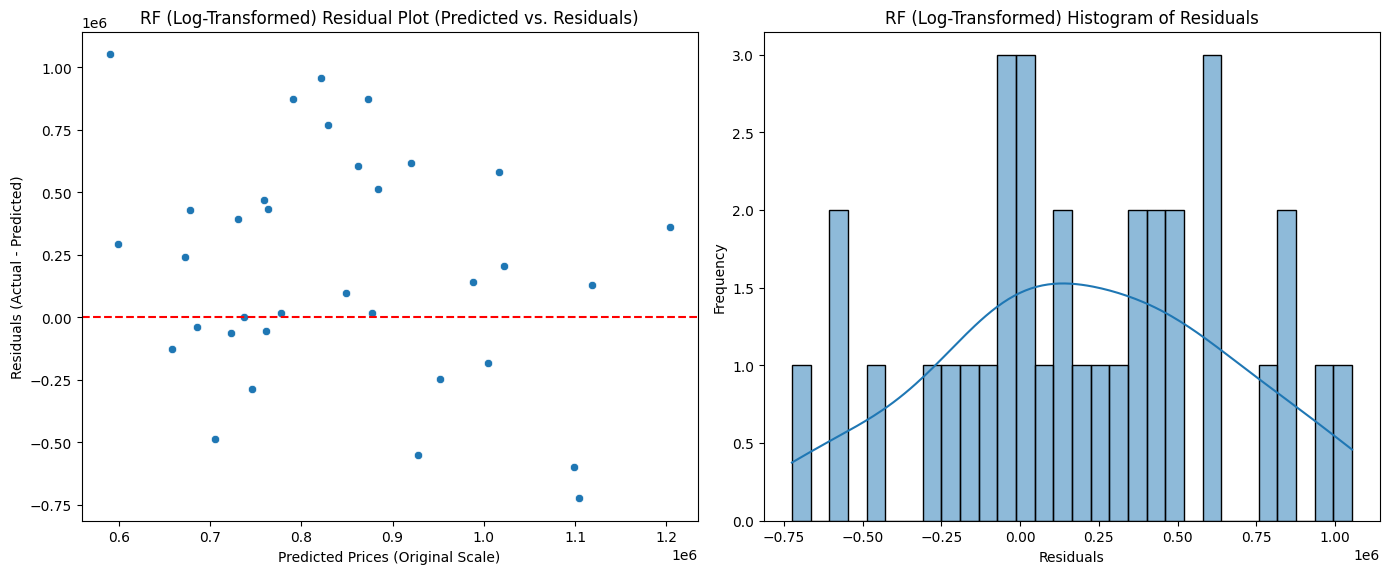

In [48]:
# Train Random Forest model on log-transformed data
rf_model_log = RandomForestRegressor(random_state=42)
rf_model_log.fit(X_train_log, y_train_log)

# Make predictions and inverse transform them
y_pred_log_rf = rf_model_log.predict(X_test_log)
y_pred_rf_original = np.expm1(y_pred_log_rf) # Inverse log1p

# Evaluate performance on original scale
mae_rf_log = mean_absolute_error(y_test, y_pred_rf_original)
r2_rf_log = r2_score(y_test, y_pred_rf_original)

print(f"Random Forest (Log-Transformed) MAE: {mae_rf_log}")
print(f"Random Forest (Log-Transformed) R2 Score: {r2_rf_log}")

# Plot residuals for Random Forest (log-transformed target)
residuals_rf_log = y_test - y_pred_rf_original

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_rf_original, y=residuals_rf_log)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF (Log-Transformed) Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_log, kde=True, bins=30)
plt.title('RF (Log-Transformed) Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Applying Log Transformation to Target Variable

In [43]:
import numpy as np

# Apply log transformation to the target variable
y_log = np.log1p(df['Price_INR'])

# Re-split the data with the log-transformed target
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

print("Log transformation applied to Price_INR and data re-split.")

Log transformation applied to Price_INR and data re-split.


### Re-training and Evaluating Linear Regression with Log-Transformed Target

Linear Regression (Log-Transformed) MAE: 377854.2805477502
Linear Regression (Log-Transformed) R2 Score: -0.15992738281238084


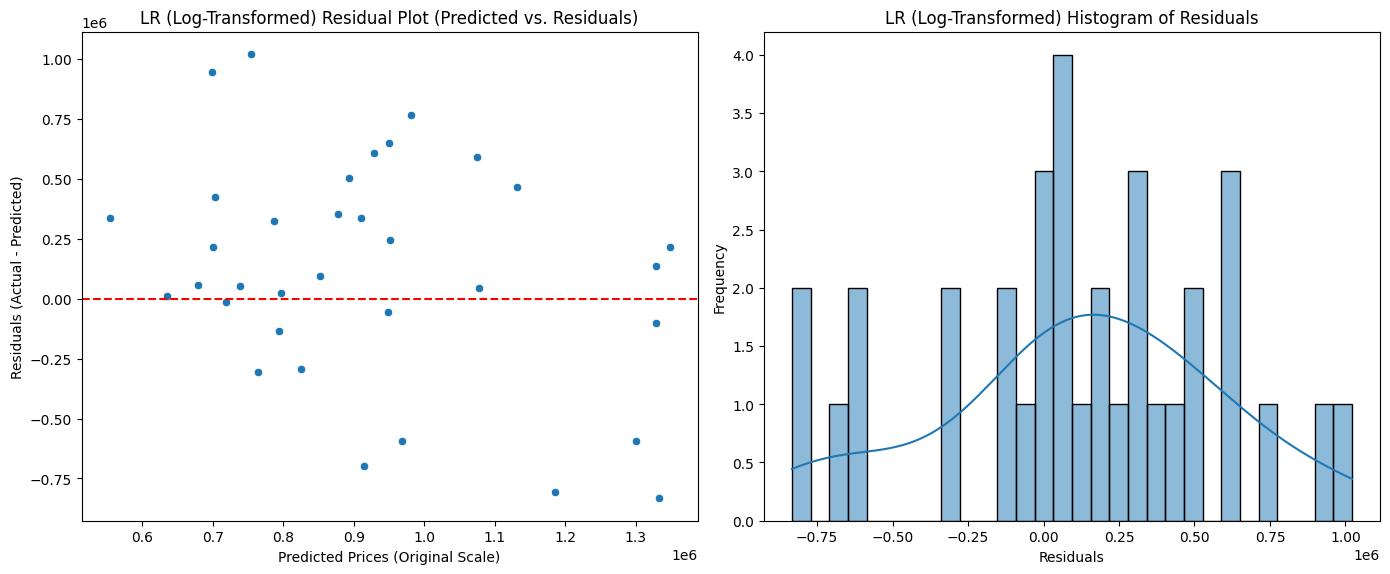

In [44]:
# Train Linear Regression model on log-transformed data
lr_model_log = LinearRegression()
lr_model_log.fit(X_train_log, y_train_log)

# Make predictions and inverse transform them
y_pred_log_lr = lr_model_log.predict(X_test_log)
y_pred_lr_original = np.expm1(y_pred_log_lr) # Inverse log1p

# Evaluate performance on original scale
mae_lr_log = mean_absolute_error(y_test, y_pred_lr_original)
r2_lr_log = r2_score(y_test, y_pred_lr_original)

print(f"Linear Regression (Log-Transformed) MAE: {mae_lr_log}")
print(f"Linear Regression (Log-Transformed) R2 Score: {r2_lr_log}")

# Plot residuals for Linear Regression (log-transformed target)
residuals_lr_log = y_test - y_pred_lr_original

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_lr_original, y=residuals_lr_log)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('LR (Log-Transformed) Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_lr_log, kde=True, bins=30)
plt.title('LR (Log-Transformed) Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Re-training and Evaluating Random Forest with Log-Transformed Target

Random Forest (Log-Transformed) MAE: 395034.5238196462
Random Forest (Log-Transformed) R2 Score: -0.23874187007890058


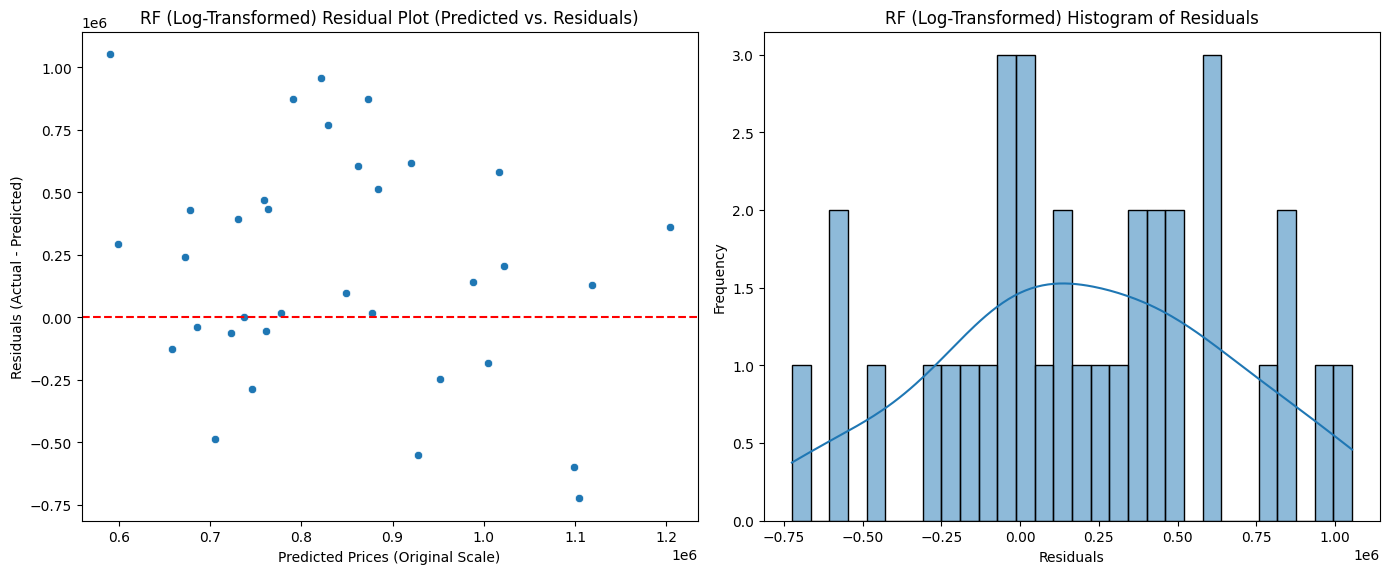

In [45]:
# Train Random Forest model on log-transformed data
rf_model_log = RandomForestRegressor(random_state=42)
rf_model_log.fit(X_train_log, y_train_log)

# Make predictions and inverse transform them
y_pred_log_rf = rf_model_log.predict(X_test_log)
y_pred_rf_original = np.expm1(y_pred_log_rf) # Inverse log1p

# Evaluate performance on original scale
mae_rf_log = mean_absolute_error(y_test, y_pred_rf_original)
r2_rf_log = r2_score(y_test, y_pred_rf_original)

print(f"Random Forest (Log-Transformed) MAE: {mae_rf_log}")
print(f"Random Forest (Log-Transformed) R2 Score: {r2_rf_log}")

# Plot residuals for Random Forest (log-transformed target)
residuals_rf_log = y_test - y_pred_rf_original

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_rf_original, y=residuals_rf_log)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF (Log-Transformed) Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_log, kde=True, bins=30)
plt.title('RF (Log-Transformed) Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Identify and Remove Outliers in `Price_INR` using IQR Method

In [51]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for Price_INR
Q1 = df['Price_INR'].quantile(0.25)
Q3 = df['Price_INR'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Price_INR'] < lower_bound) | (df['Price_INR'] > upper_bound)]

print(f"Number of outliers identified: {len(outliers)}")
print(f"Outliers:\n{outliers[['Price_INR']]}")

# Remove outliers
df_no_outliers = df[~((df['Price_INR'] < lower_bound) | (df['Price_INR'] > upper_bound))]

print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")

Number of outliers identified: 0
Outliers:
Empty DataFrame
Columns: [Price_INR]
Index: []

Original DataFrame shape: (170, 12)
DataFrame shape after outlier removal: (170, 12)


### Visualize `Price_INR` Distribution After Outlier Removal

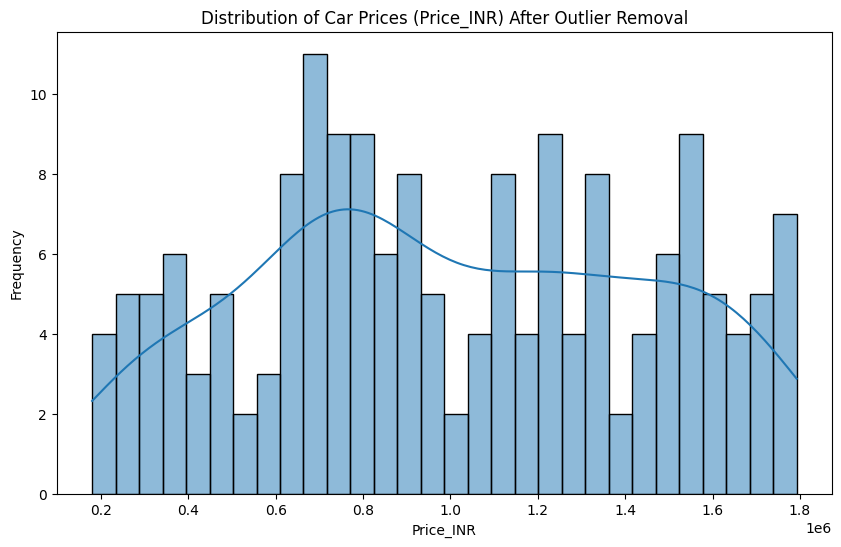

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df_no_outliers['Price_INR'], kde=True, bins=30)
plt.title('Distribution of Car Prices (Price_INR) After Outlier Removal')
plt.xlabel('Price_INR')
plt.ylabel('Frequency')
plt.show()

### Hyperparameter Tuning for Random Forest using GridSearchCV

In [7]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd # Added pandas import

# Re-load data and define X, y to ensure they are available in this cell
df = pd.read_csv("/content/cleane_used cars.csv")
X = df.drop('Price_INR', axis=1)
y = df['Price_INR']

# Apply log transformation to the target variable and re-split data to ensure X_train_log etc. are defined
y_log = np.log1p(df['Price_INR'])
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# Using n_jobs=-1 to utilize all available CPU cores for faster computation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

# Fit GridSearchCV to the training data (log-transformed target)
grid_search.fit(X_train_log, y_train_log)

print("GridSearchCV completed.")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
GridSearchCV completed.


In [10]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd # Added pandas import if not already present in previous cells needed for df

# Re-load data and define X, y to ensure they are available in this cell, consistent with dc8305ae
df = pd.read_csv("/content/cleane_used cars.csv")
X = df.drop('Price_INR', axis=1)
y = df['Price_INR']

# Re-split the original data to get y_test on the original scale
# Ensure X_train, X_test, y_train, y_test are defined with the original target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the best parameters and best score found
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best MAE (negative): {grid_search.best_score_}")

# Retrieve the best model
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model and inverse transform them
y_pred_best_rf_log = best_rf_model.predict(X_test_log)
y_pred_best_rf_original = np.expm1(y_pred_best_rf_log) # Inverse log1p

# Evaluate performance on original scale using the correctly defined y_test
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf_original)
r2_best_rf = r2_score(y_test, y_pred_best_rf_original)

print(f"Random Forest (Tuned, Log-Transformed) MAE: {mae_best_rf}")
print(f"Random Forest (Tuned, Log-Transformed) R2 Score: {r2_best_rf}")

Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best MAE (negative): -0.4473014487604328
Random Forest (Tuned, Log-Transformed) MAE: 390728.9480027951
Random Forest (Tuned, Log-Transformed) R2 Score: -0.15827783897253167


### Visualize Tuned Random Forest Residuals

Let's plot the residuals for the best Random Forest model to see the impact of tuning and log transformation.

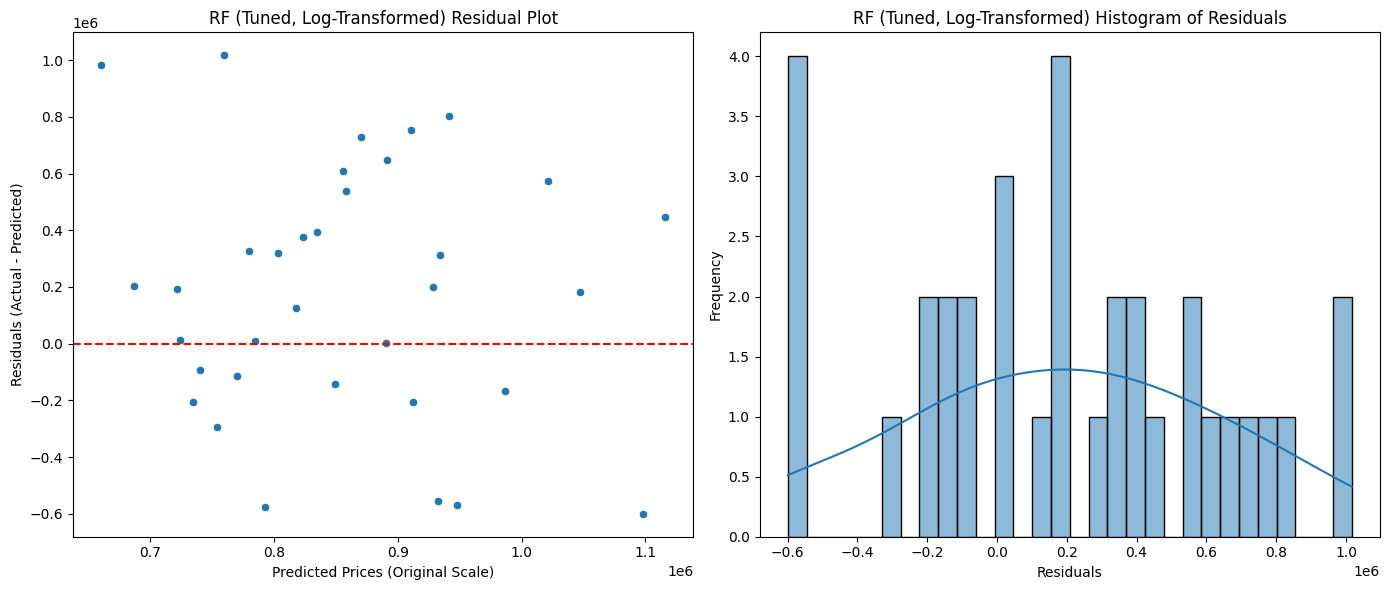

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals_best_rf = y_test - y_pred_best_rf_original

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_best_rf_original, y=residuals_best_rf)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF (Tuned, Log-Transformed) Residual Plot')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_best_rf, kde=True, bins=30)
plt.title('RF (Tuned, Log-Transformed) Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

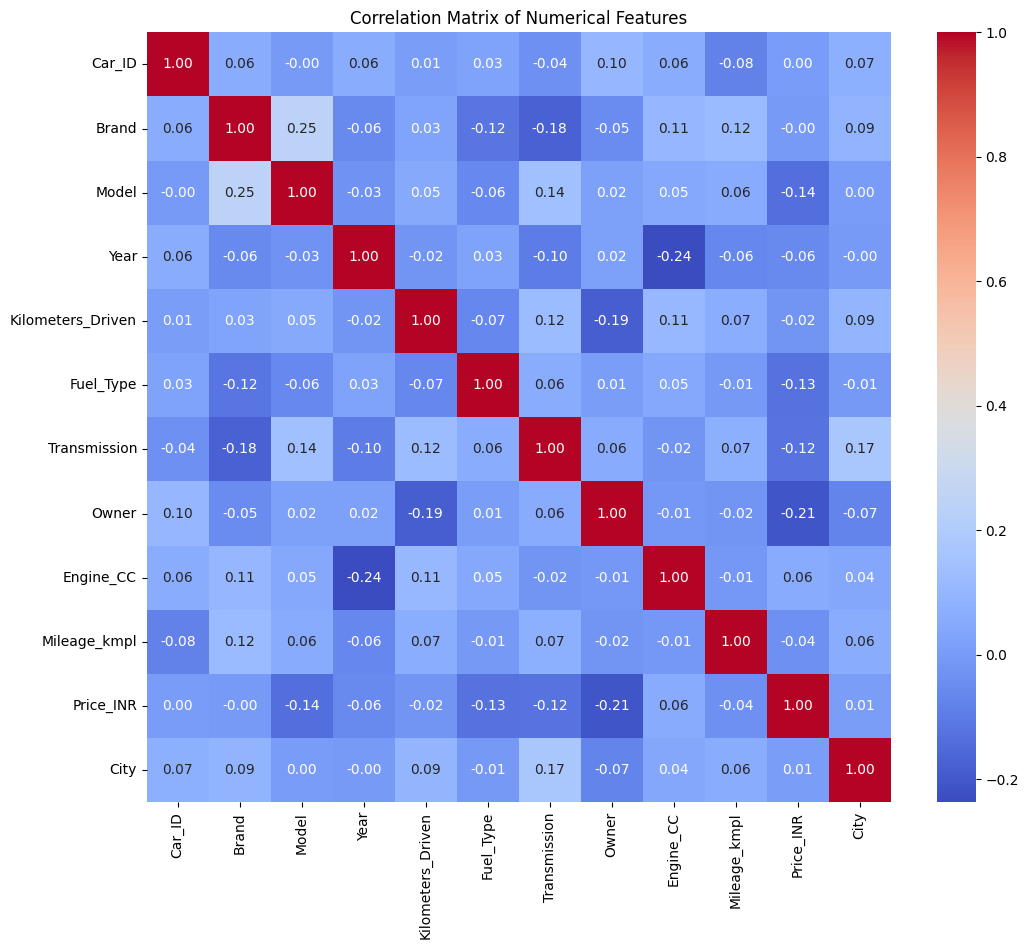

In [15]:
plt.figure(figsize=(12, 10))
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

<Figure size 1000x600 with 0 Axes>

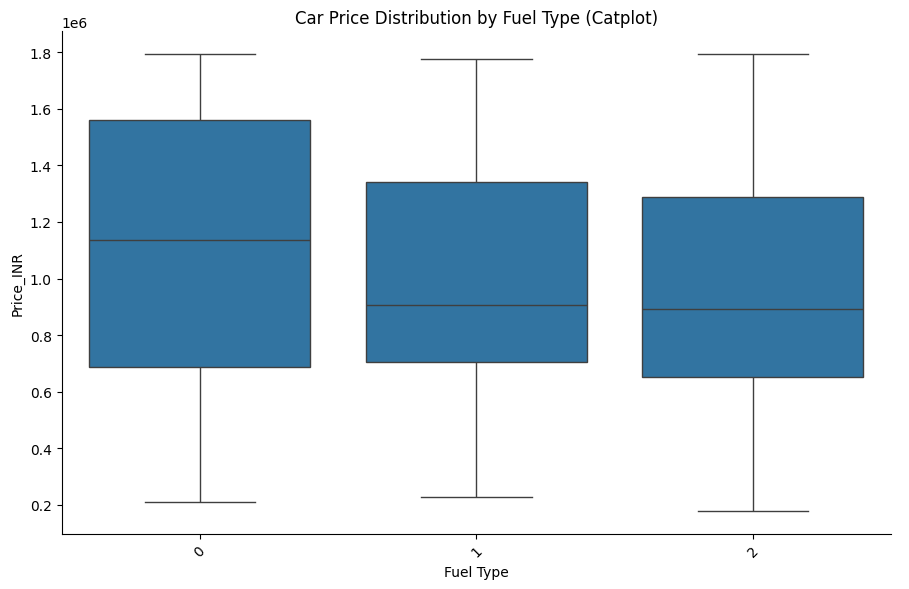

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure df is loaded if not already from previous cells
# df = pd.read_csv("/content/cleane_used cars.csv")

plt.figure(figsize=(10, 6))
sns.catplot(data=df, x='Fuel_Type', y='Price_INR', kind='box', height=6, aspect=1.5)
plt.title('Car Price Distribution by Fuel Type (Catplot)')
plt.xlabel('Fuel Type')
plt.ylabel('Price_INR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### One-Hot Encoding of Categorical Features

In [20]:
import pandas as pd

# Identify categorical columns (assuming these are the relevant ones from previous analysis or domain knowledge)
categorical_cols = ['Fuel_Type', 'Transmission', 'Owner', 'City']

# Create dummy variables for each categorical column
# We'll create a new DataFrame X_encoded to hold the features, ensuring we don't modify the original 'df' unnecessarily.
# The 'X' variable already contains the features without 'Price_INR'.

X_encoded = X.copy()

for col in categorical_cols:
    if col in X_encoded.columns:
        dummies = pd.get_dummies(X_encoded[col], prefix=col, drop_first=True) # drop_first to avoid multicollinearity
        X_encoded = pd.concat([X_encoded, dummies], axis=1)
        X_encoded = X_encoded.drop(columns=[col]) # Drop the original categorical column

print(f"Original X shape: {X.shape}")
print(f"Encoded X shape: {X_encoded.shape}")
display(X_encoded.head())

Original X shape: (170, 11)
Encoded X shape: (170, 17)


,Car_ID,Brand,Model,Year,Kilometers_Driven,Engine_CC,Mileage_kmpl,Fuel_Type_1,Fuel_Type_2,Transmission_1,Owner_2,Owner_3,Owner_4,City_1,City_2,City_3,City_4
0,1,2,12,2016,69196,1598.0,23.3,False,True,True,False,False,False,False,False,True,False
1,4,5,19,2011,29312,1998.0,16.2,True,False,True,False,True,False,False,False,True,False
2,6,4,19,2010,66024,1497.0,21.4,False,True,False,False,True,False,False,False,False,False
3,7,3,21,2014,180682,1498.0,23.1,True,False,True,True,False,False,False,False,False,True
4,8,6,15,2015,184467,1998.0,10.6,True,False,True,True,False,False,False,False,False,True


### Re-splitting Data and Re-training Random Forest with One-Hot Encoded Features and Log-Transformed Target

Data re-split with one-hot encoded features and log-transformed target.

Random Forest (Encoded Features, Log-Transformed) MAE: 402476.8597541504
Random Forest (Encoded Features, Log-Transformed) R2 Score: -0.2556115481384662


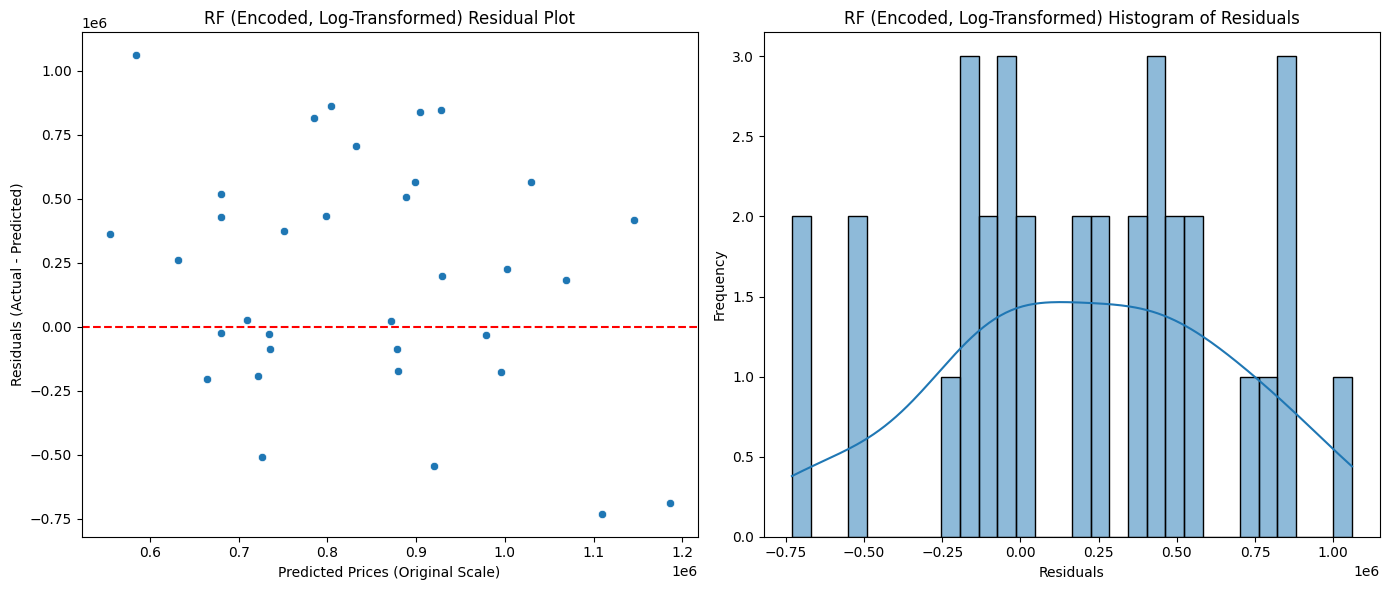

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df, y and X are loaded and defined for consistency
df = pd.read_csv("/content/cleane_used cars.csv")
X = df.drop('Price_INR', axis=1)
y = df['Price_INR']

# Re-apply one-hot encoding to get X_encoded (to make this cell self-contained)
categorical_cols = ['Fuel_Type', 'Transmission', 'Owner', 'City']
X_encoded = X.copy()
for col in categorical_cols:
    if col in X_encoded.columns:
        dummies = pd.get_dummies(X_encoded[col], prefix=col, drop_first=True)
        X_encoded = pd.concat([X_encoded, dummies], axis=1)
        X_encoded = X_encoded.drop(columns=[col])

# Apply log transformation to the target variable
y_log = np.log1p(y)

# Re-split the data using X_encoded and y_log
X_train_encoded, X_test_encoded, y_train_log, y_test_log = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)

# Also create y_test on the original scale for evaluation metrics
# To get y_test (original scale) that corresponds to X_test_encoded/y_test_log
_, _, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data re-split with one-hot encoded features and log-transformed target.")

# Train Random Forest model on encoded and log-transformed data
rf_model_encoded = RandomForestRegressor(random_state=42)
rf_model_encoded.fit(X_train_encoded, y_train_log)

# Make predictions and inverse transform them
y_pred_encoded_log_rf = rf_model_encoded.predict(X_test_encoded)
y_pred_encoded_rf_original = np.expm1(y_pred_encoded_log_rf) # Inverse log1p

# Evaluate performance on original scale
mae_rf_encoded = mean_absolute_error(y_test, y_pred_encoded_rf_original)
r2_rf_encoded = r2_score(y_test, y_pred_encoded_rf_original)

print(f"\nRandom Forest (Encoded Features, Log-Transformed) MAE: {mae_rf_encoded}")
print(f"Random Forest (Encoded Features, Log-Transformed) R2 Score: {r2_rf_encoded}")

# Plot residuals for Random Forest (encoded features, log-transformed target)
residuals_rf_encoded = y_test - y_pred_encoded_rf_original

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_encoded_rf_original, y=residuals_rf_encoded)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RF (Encoded, Log-Transformed) Residual Plot')
plt.xlabel('Predicted Prices (Original Scale)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_encoded, kde=True, bins=30)
plt.title('RF (Encoded, Log-Transformed) Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Joint Kernel Density Estimate Plot for Price_INR and Engine_CC

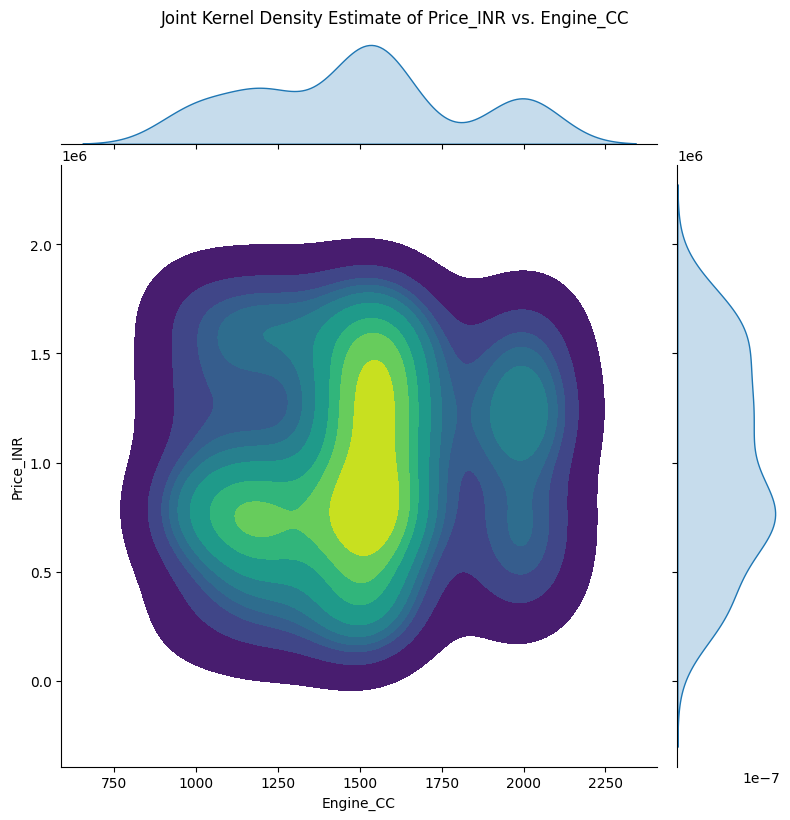

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded (if not already from previous cells)
df = pd.read_csv("/content/cleane_used cars.csv")

sns.jointplot(x='Engine_CC', y='Price_INR', data=df, kind='kde', height=8, cmap='viridis', fill=True)
plt.suptitle('Joint Kernel Density Estimate of Price_INR vs. Engine_CC', y=1.02) # Adjust suptitle position
plt.show()

### Conditional Kernel Density Estimate of Price_INR and Engine_CC by Fuel_Type

/usr/local/lib/python3.13/dist-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


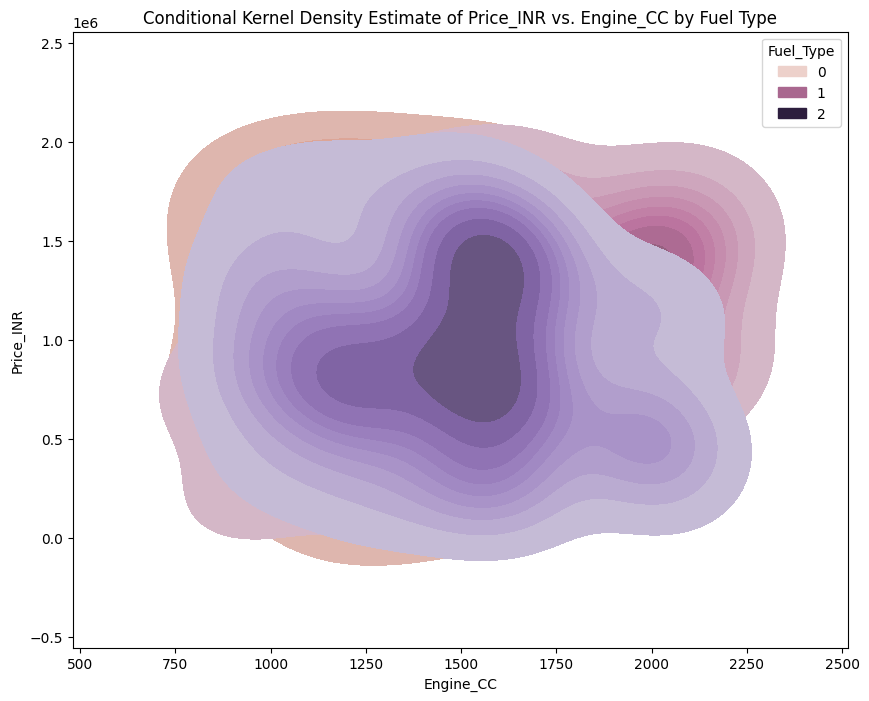

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded (if not already from previous cells)
df = pd.read_csv("/content/cleane_used cars.csv")

plt.figure(figsize=(10, 8))
sns.kdeplot(data=df, x='Engine_CC', y='Price_INR', hue='Fuel_Type', fill=True, cmap='viridis')
plt.title('Conditional Kernel Density Estimate of Price_INR vs. Engine_CC by Fuel Type')
plt.xlabel('Engine_CC')
plt.ylabel('Price_INR')
plt.show()

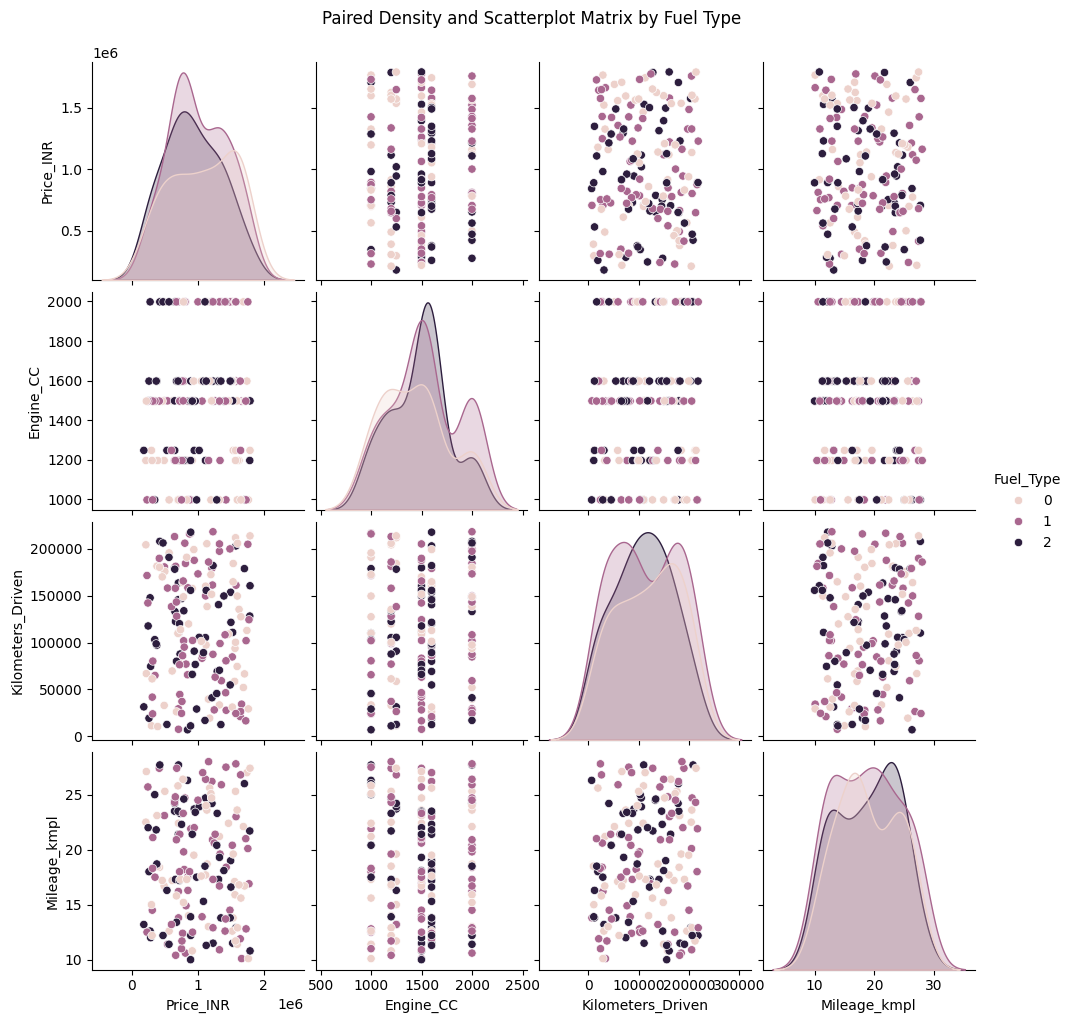

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded (if not already from previous cells)
df = pd.read_csv("/content/cleane_used cars.csv")

# Select relevant numerical features for the pair plot
# Include 'Fuel_Type' to observe conditional relationships
features_for_pairplot = ['Price_INR', 'Engine_CC', 'Kilometers_Driven', 'Mileage_kmpl', 'Fuel_Type']

sns.pairplot(df[features_for_pairplot], hue='Fuel_Type', diag_kind='kde')
plt.suptitle('Paired Density and Scatterplot Matrix by Fuel Type', y=1.02)
plt.show()

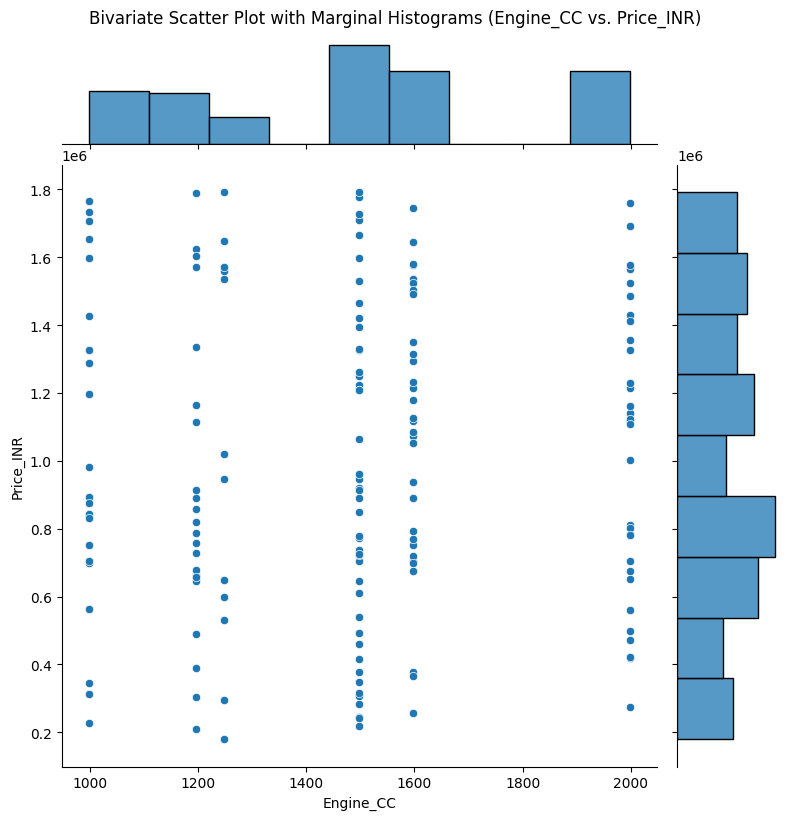

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded (if not already from previous cells)
df = pd.read_csv("/content/cleane_used cars.csv")

# Create a joint plot with scatter plot and marginal histograms
sns.jointplot(x='Engine_CC', y='Price_INR', data=df, kind='scatter', height=8)
plt.suptitle('Bivariate Scatter Plot with Marginal Histograms (Engine_CC vs. Price_INR)', y=1.02)
plt.show()

### Exploring Different Cubehelix Palettes


Generating pairplot with Cubehelix palette: ch:start=.2,rot=-.3


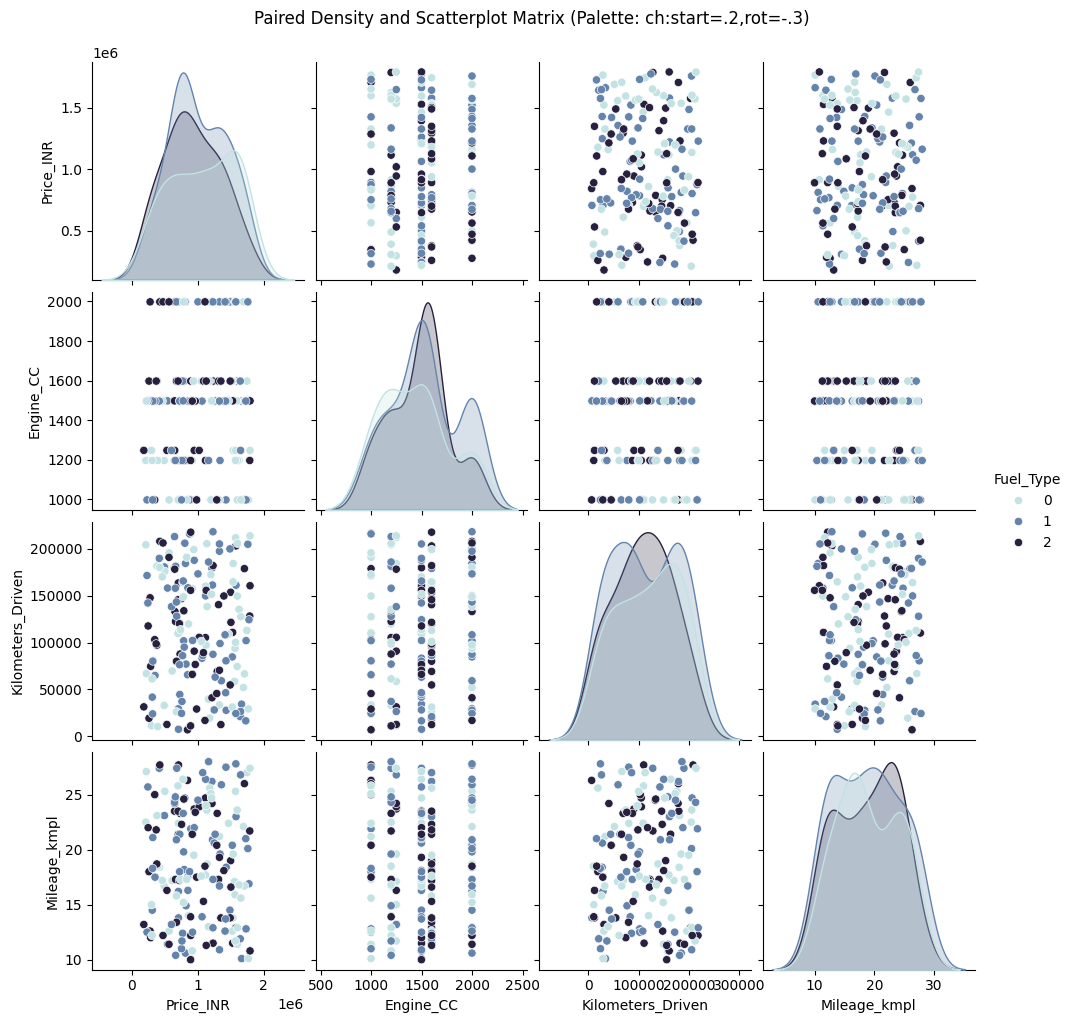


Generating pairplot with Cubehelix palette: ch:start=.0,rot=.4


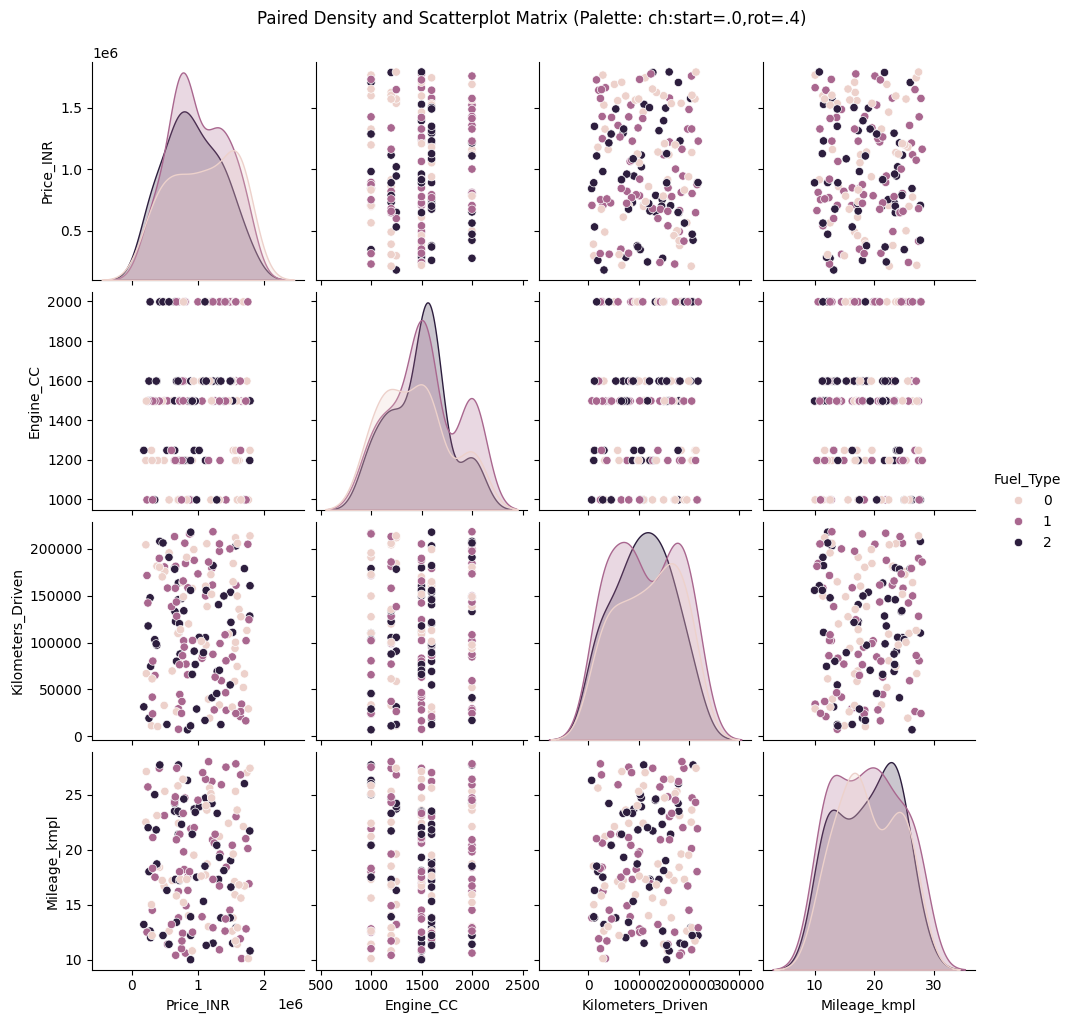


Generating pairplot with Cubehelix palette: ch:start=.5,rot=0


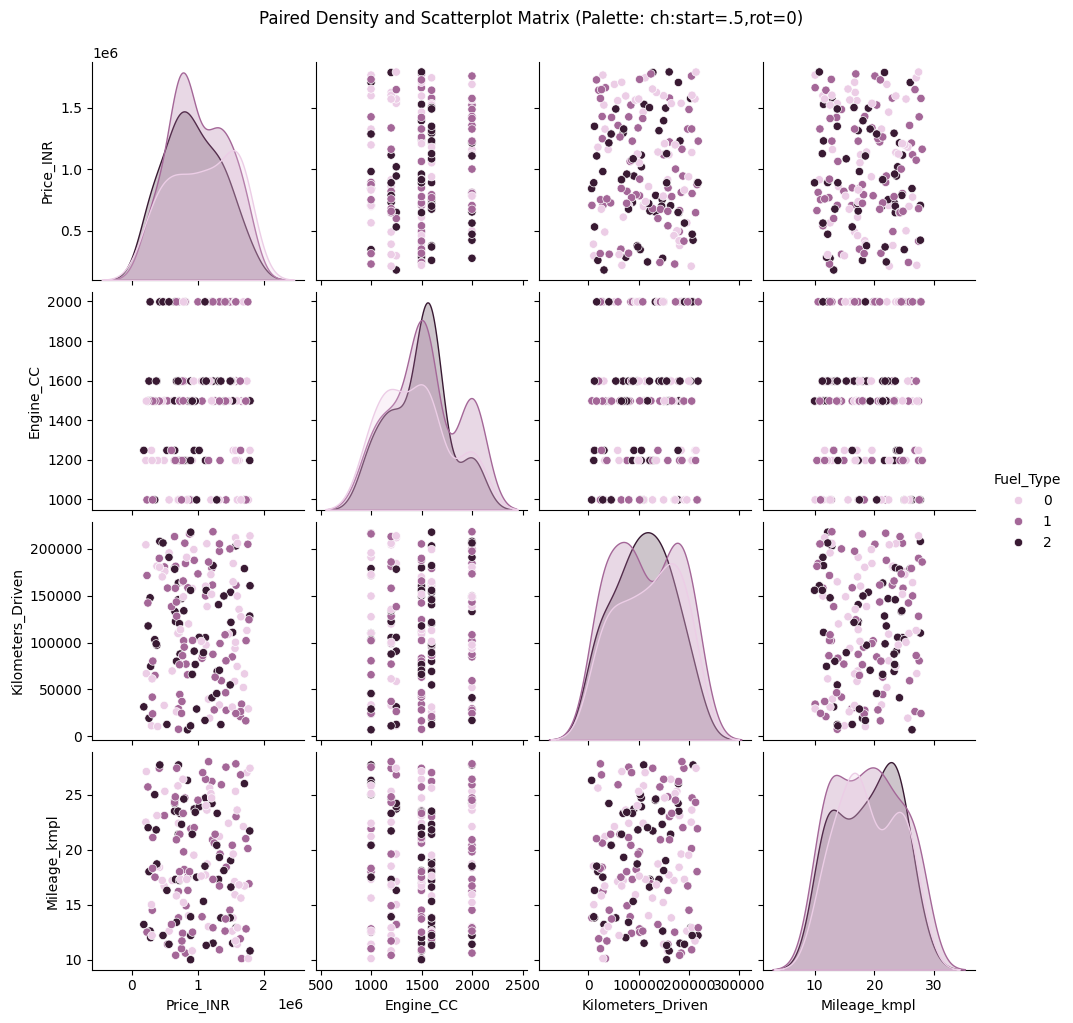

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df and features_for_pairplot are already defined from previous cells
# If not, uncomment the following lines:
# import pandas as pd
# df = pd.read_csv("/content/cleane_used cars.csv")
# features_for_pairplot = ['Price_INR', 'Engine_CC', 'Kilometers_Driven', 'Mileage_kmpl', 'Fuel_Type']

palettes = ['ch:start=.2,rot=-.3', 'ch:start=.0,rot=.4', 'ch:start=.5,rot=0']

for i, palette_str in enumerate(palettes):
    print(f"\nGenerating pairplot with Cubehelix palette: {palette_str}")
    g = sns.pairplot(df[features_for_pairplot], hue='Fuel_Type', diag_kind='kde', palette=palette_str)
    g.fig.suptitle(f'Paired Density and Scatterplot Matrix (Palette: {palette_str})', y=1.02)
    plt.show()

### FacetGrid: Engine_CC vs. Price_INR by Fuel_Type

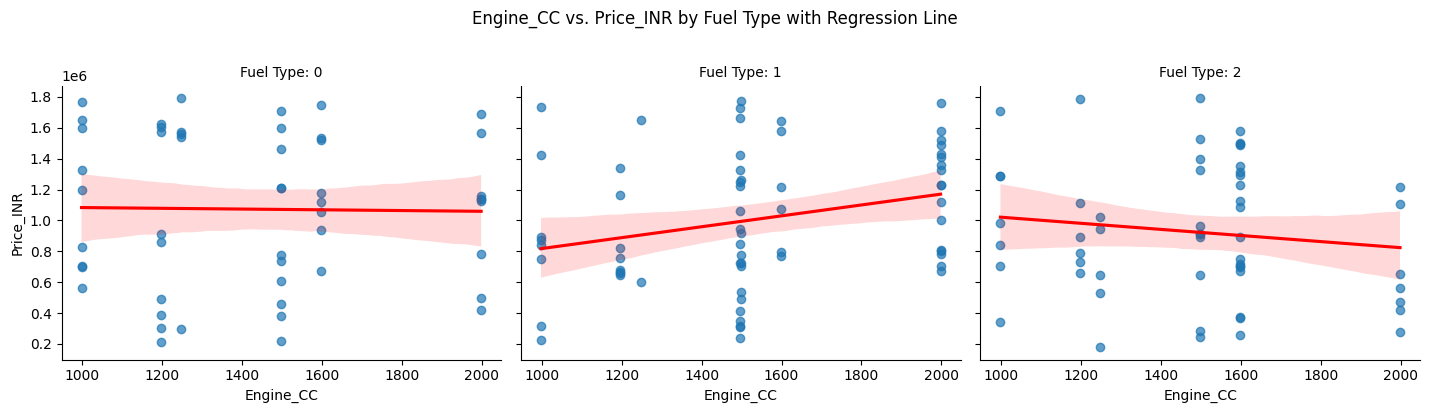

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded (if not already from previous cells)
# df = pd.read_csv("/content/cleane_used cars.csv")

# Create a FacetGrid with 'Fuel_Type' on the columns
g = sns.FacetGrid(df, col='Fuel_Type', col_wrap=3, height=4, aspect=1.2)

# Map a scatter plot with a regression line to each facet
g.map(sns.regplot, 'Engine_CC', 'Price_INR', scatter_kws={'alpha':0.7}, line_kws={'color':'red'})

# Add titles and labels
g.set_axis_labels('Engine_CC', 'Price_INR')
g.set_titles('Fuel Type: {col_name}')
plt.suptitle('Engine_CC vs. Price_INR by Fuel Type with Regression Line', y=1.02)
plt.tight_layout()
plt.show()

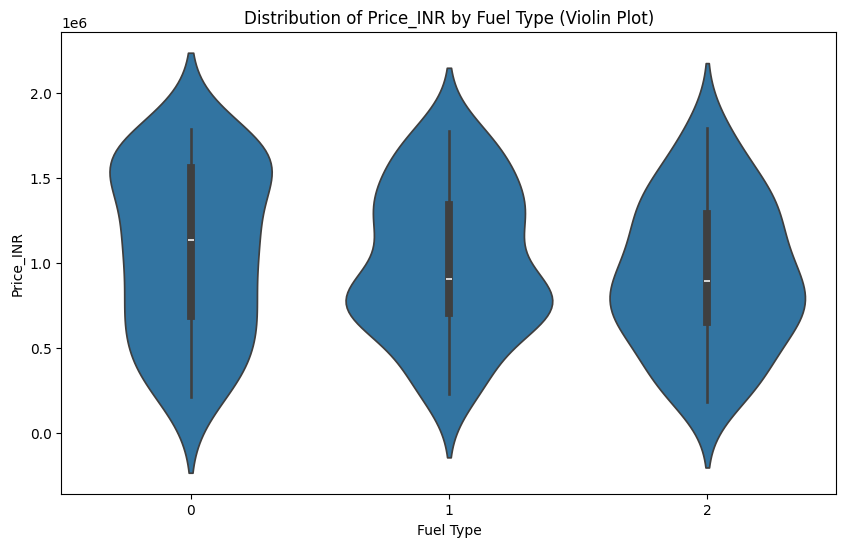

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded if not already from previous cells
# df = pd.read_csv("/content/cleane_used cars.csv")

plt.figure(figsize=(10, 6))
sns.violinplot(x='Fuel_Type', y='Price_INR', data=df)
plt.title('Distribution of Price_INR by Fuel Type (Violin Plot)')
plt.xlabel('Fuel Type')
plt.ylabel('Price_INR')
plt.show()

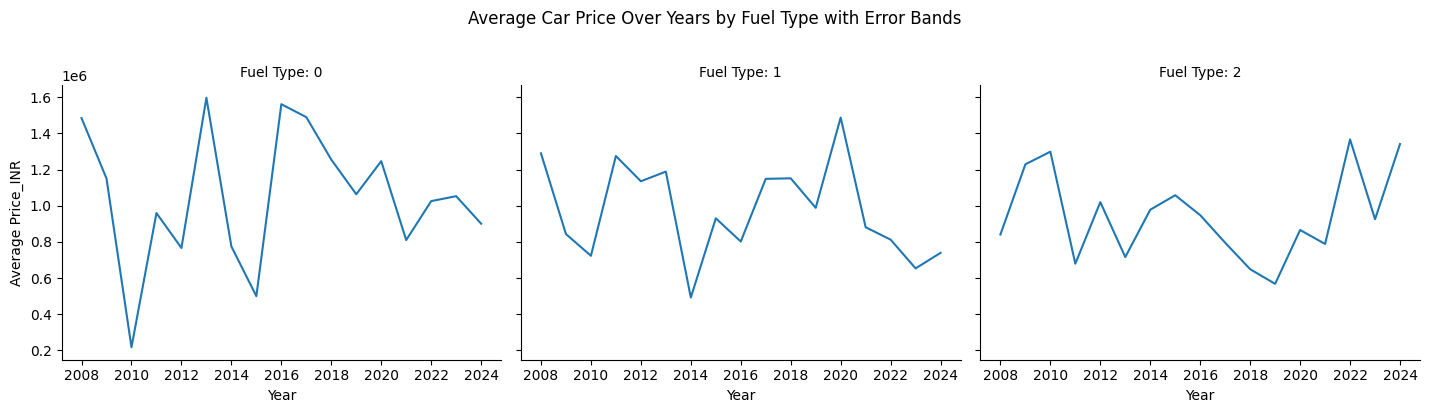

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df is loaded (if not already from previous cells)
# df = pd.read_csv("/content/cleane_used cars.csv")

# Group data by Year and Fuel_Type to calculate mean Price_INR for trend analysis
df_yearly_avg = df.groupby(['Year', 'Fuel_Type'])['Price_INR'].mean().reset_index()

# Create a small multiple line plot using relplot with error bands (95% confidence interval)
g = sns.relplot(
    data=df_yearly_avg,
    x='Year', y='Price_INR', col='Fuel_Type', kind='line', col_wrap=3, height=4, aspect=1.2,
    markers=True, dashes=False, errorbar=('ci', 95) # Using errorbar parameter as recommended
)

g.set_axis_labels('Year', 'Average Price_INR')
g.set_titles('Fuel Type: {col_name}')
plt.suptitle('Average Car Price Over Years by Fuel Type with Error Bands', y=1.02)
plt.tight_layout()
plt.show()